## imports

In [13]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory
from typing import Annotated
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from langgraph.graph import MessagesState
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

## models

In [ ]:
#llm
##################

llm = init_chat_model("ollama:nemotron-3-super:cloud",base_url="https://ollama.com")
llm2 = init_chat_model("ollama:nemotron-3-super:cloud",base_url="https://ollama.com")
# Initialize the model (you can use models like gemini-2.5-flash or gemini-pro)



response = llm.invoke("What is the color of the sky answer in one word?")
print(response.content)

Blue


## topic 1: Basic logic of graph

### with state dict

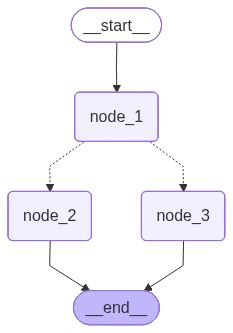

In [32]:
from typing import TypedDict

#state
class State(TypedDict):
    graph_state: str



# node

def node_1(state):
    print("----Node1----")
    return {"graph_state": state['graph_state'] + " is"}

def node_2(state):
    print("----Node2----")
    return {"graph_state": state['graph_state'] + " HAPPY"}

def node_3(state):
    print("----Node3----")
    return {"graph_state": state['graph_state'] + " SAD"}

def node_4(state):
    print("----Node4----")
    return {"graph_state": state['graph_state'] + " ANGERY"}


# edge
# conditionaL edge
from typing import Literal # will always return the type written inside the literal

def decide_mood(state)-> Literal["node_2", "node_3"]:
    user_input = state["graph_state"]

    import random
    if random.random() < 0.5:
        return "node_2"
    return "node_3"



## create graph

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge('node_2', END)
builder.add_edge("node_3", END)

graph = builder.compile()


# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [35]:
response = graph.invoke({"graph_state" :  "ramesh"})
response

----Node1----
----Node2----


{'graph_state': 'ramesh is HAPPY'}

In [34]:
response = graph.invoke({"graph_state" :  "ramesh"})
response

----Node1----
----Node3----


{'graph_state': 'ramesh is SAD'}

### with StateMessage class

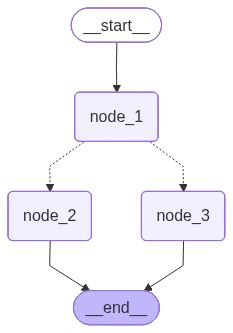

In [40]:
from typing import TypedDict
from langgraph.graph import MessagesState

#state
# class State(TypedDict):
#     graph_state: str


class State(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    graph_state: str

# node

def node_1(state):
    print("----Node1----")
    return {"graph_state": state['graph_state'] + " is", "messages" : "node1"}

def node_2(state):
    print("----Node2----")
    return {"graph_state": state['graph_state'] + " HAPPY", "messages" : "node2"}

def node_3(state):
    print("----Node3----")
    return {"graph_state": state['graph_state'] + " SAD", "messages" : "node3"}

def node_4(state):
    print("----Node4----")
    return {"graph_state": state['graph_state'] + " ANGERY", "messages" : "node4"}


# edge
# conditionaL edge
from typing import Literal # will always return the type written inside the literal

def decide_mood(state)-> Literal["node_2", "node_3"]:
    user_input = state["graph_state"]

    import random
    if random.random() < 0.5:
        return "node_2"
    return "node_3"



## create graph

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge('node_2', END)
builder.add_edge("node_3", END)

graph = builder.compile()


# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [41]:
response = graph.invoke({"graph_state" :  "ramesh"})
response

----Node1----
----Node3----


{'messages': [HumanMessage(content='node1', additional_kwargs={}, response_metadata={}, id='765ec662-5c04-44c5-86fd-f0361fcefe88'),
  HumanMessage(content='node3', additional_kwargs={}, response_metadata={}, id='ef8c1377-43af-45e7-a551-ef73c8e7d3cf')],
 'graph_state': 'ramesh is SAD'}

In [43]:
response['messages']

[HumanMessage(content='node1', additional_kwargs={}, response_metadata={}, id='765ec662-5c04-44c5-86fd-f0361fcefe88'),
 HumanMessage(content='node3', additional_kwargs={}, response_metadata={}, id='ef8c1377-43af-45e7-a551-ef73c8e7d3cf')]

In [44]:
response['graph_state']

'ramesh is SAD'

In [45]:
response = graph.invoke({"graph_state" :  "ramesh", "messages" : "START"})
response

----Node1----
----Node3----


{'messages': [HumanMessage(content='START', additional_kwargs={}, response_metadata={}, id='a73840ee-5c28-4fda-a371-836d3c6cd88b'),
  HumanMessage(content='node1', additional_kwargs={}, response_metadata={}, id='90fa3876-4e3e-4cd5-835b-aff7a7d71d85'),
  HumanMessage(content='node3', additional_kwargs={}, response_metadata={}, id='f5914594-6534-45f0-8c23-d126c0d7d7a7')],
 'graph_state': 'ramesh is SAD'}

In [46]:
response['messages']

[HumanMessage(content='START', additional_kwargs={}, response_metadata={}, id='a73840ee-5c28-4fda-a371-836d3c6cd88b'),
 HumanMessage(content='node1', additional_kwargs={}, response_metadata={}, id='90fa3876-4e3e-4cd5-835b-aff7a7d71d85'),
 HumanMessage(content='node3', additional_kwargs={}, response_metadata={}, id='f5914594-6534-45f0-8c23-d126c0d7d7a7')]

In [49]:
response['messages'][0].content

'START'

## graph with StateMessage

In [ ]:
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

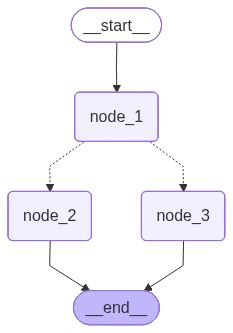

In [57]:
from typing import TypedDict
from langgraph.graph import MessagesState

class State(MessagesState): 
    pass

# node

def node_1(state):
    print("----Node1----")
    ans = state['messages'][-1].content + " is"
    return {"messages" : ans}

def node_2(state):
    print("----Node2----")
    ans = state['messages'][-1].content + " HAPPY"
    return {"messages" : ans} 
def node_3(state):
    print("----Node3----")
    ans = state['messages'][-1].content + " SAD"
    return {"messages" : ans} 

def node_4(state):
    print("----Node4----")
    ans = state['messages'][-1].content + " ANGRY"
    return {"messages" : ans} 

# edge
# conditionaL edge
from typing import Literal # will always return the type written inside the literal

def decide_mood(state)-> Literal["node_2", "node_3"]:
    user_input = state["messages"]

    import random
    if random.random() < 0.5:
        return "node_2"
    return "node_3"



## create graph

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge('node_2', END)
builder.add_edge("node_3", END)

graph = builder.compile()


# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [58]:
response = graph.invoke({"messages" : HumanMessage("mukesh")})
response

----Node1----
----Node3----


{'messages': [HumanMessage(content='mukesh', additional_kwargs={}, response_metadata={}, id='288452da-14a9-489a-924d-f19c0dc14e5f'),
  HumanMessage(content='mukesh is', additional_kwargs={}, response_metadata={}, id='4b78a3a4-c117-494b-9db6-00349bdcf3f2'),
  HumanMessage(content='mukesh is SAD', additional_kwargs={}, response_metadata={}, id='15bd2d34-559d-431f-8f33-d93603fd67fa')]}

In [60]:
response = graph.invoke({"messages" : "Elon"})
response

----Node1----
----Node3----


{'messages': [HumanMessage(content='Elon', additional_kwargs={}, response_metadata={}, id='f722e1b4-0cf6-4ec3-b4b1-3dfd68644aa0'),
  HumanMessage(content='Elon is', additional_kwargs={}, response_metadata={}, id='5e219db3-4027-4c38-a112-5f88fac061ea'),
  HumanMessage(content='Elon is SAD', additional_kwargs={}, response_metadata={}, id='f35aefc6-00c1-4d11-b57f-1318d4dc7213')]}

In [61]:
response['messages']

[HumanMessage(content='Elon', additional_kwargs={}, response_metadata={}, id='f722e1b4-0cf6-4ec3-b4b1-3dfd68644aa0'),
 HumanMessage(content='Elon is', additional_kwargs={}, response_metadata={}, id='5e219db3-4027-4c38-a112-5f88fac061ea'),
 HumanMessage(content='Elon is SAD', additional_kwargs={}, response_metadata={}, id='f35aefc6-00c1-4d11-b57f-1318d4dc7213')]

In [63]:
response['messages'][-1].content

'Elon is SAD'

### typedict base

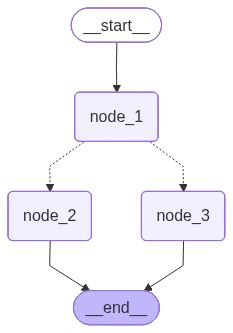

In [66]:
from typing import Literal

class TypedDictState(TypedDict):
    name: str
    mood: Literal["happy","sad"]



import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

def node_1(state):
    print("---Node 1---")
    return {"name": "Hi " + state['name']}

def node_2(state):
    print("---Node 2---")
    return {"mood": "happy"}

def node_3(state):
    print("---Node 3---")
    return {"mood": "sad"}

def decide_mood(state) -> Literal["node_2", "node_3"]:
        
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"
    
    # 50% of the time, we return Node 3
    return "node_3"

# Build graph
builder = StateGraph(TypedDictState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [68]:
response = graph.invoke({"name":"Lance"})

---Node 1---
---Node 3---


In [69]:
response

{'name': 'Hi Lance', 'mood': 'sad'}

In [ ]:
from dataclasses import dataclass

@dataclass
class DataclassState:
    name: str
    mood: Literal["happy","sad"]

def node_1(state):
    print("---Node 1---")
    return {"name": state.name + " is ... "}

# Build graph
builder = StateGraph(DataclassState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

### pydentic

In [71]:
from pydantic import BaseModel, field_validator, ValidationError

class PydanticState(BaseModel):
    name: str
    mood: str # "happy" or "sad" 

    @field_validator('mood')
    @classmethod
    def validate_mood(cls, value):
        # Ensure the mood is either "happy" or "sad"
        if value not in ["happy", "sad"]:
            raise ValueError("Each mood must be either 'happy' or 'sad'")
        return value

try:
    state = PydanticState(name="John Doe", mood="mad")
except ValidationError as e:
    print("Validation Error:", e)

Validation Error: 1 validation error for PydanticState
mood
  Value error, Each mood must be either 'happy' or 'sad' [type=value_error, input_value='mad', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error


In [73]:

try:
    state = PydanticState(name="John Doe", mood="happy")
    print(state)
except ValidationError as e:
    print("Validation Error:", e)

name='John Doe' mood='happy'


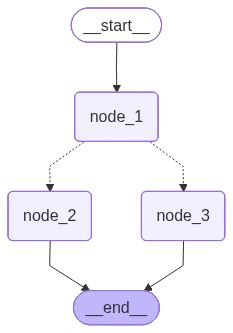

In [78]:
from pydantic import BaseModel, field_validator, ValidationError

class PydanticState(BaseModel):
    name: str
    mood: str # "happy" or "sad" 

    @field_validator('mood')
    @classmethod
    def validate_mood(cls, value):
        # Ensure the mood is either "happy" or "sad"
        if value not in ["happy", "sad"]:
            raise ValueError("Each mood must be either 'happy' or 'sad'")
        return value


def node_1(state):
    print("---Node 1---")
    return {"name": state.name + " is ... "}

def node_2(state):
    print("---Node 2---")
    return {"mood": "happy"}

def node_3(state):
    print("---Node 3---")
    return {"mood": "sad"}

def decide_mood(state) -> Literal["node_2", "node_3"]:
        
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"
    
    # 50% of the time, we return Node 3
    return "node_3"


# Build graph
builder = StateGraph(PydanticState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [79]:
graph.invoke(PydanticState(name="Lance",mood="sad"))

---Node 1---
---Node 3---


{'name': 'Lance is ... ', 'mood': 'sad'}

In [ ]:
graph.invoke(Py.danticState(name="Lance",mood="ruf"))

ValidationError: 1 validation error for PydanticState
mood
  Value error, Each mood must be either 'happy' or 'sad' [type=value_error, input_value='ruf', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error

## need of reducer

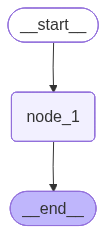

In [83]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state['foo'] + 1}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [84]:
graph.invoke({"foo" : 1})

---Node 1---


{'foo': 2}

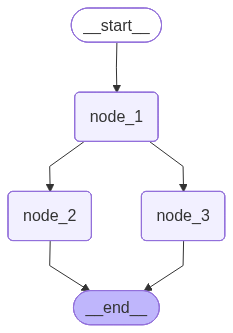

In [85]:
# branchnig

class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state['foo'] + 1}

def node_2(state):
    print("---Node 2---")
    return {"foo": state['foo'] + 1}

def node_3(state):
    print("---Node 3---")
    return {"foo": state['foo'] + 1}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [86]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"foo" : 1})
except InvalidUpdateError as e:
    print(f"InvalidUpdateError occurred: {e}")


---Node 1---
---Node 2---
---Node 3---
InvalidUpdateError occurred: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


## reducer function

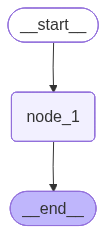

In [87]:
## reducer

from operator import add
from typing import Annotated

class State(TypedDict):
    foo: Annotated[list[int], add]

def node_1(state):
    print("---Node 1---")
    return {"foo": [state['foo'][0] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [88]:
graph.invoke({"foo" : [1]})

---Node 1---


{'foo': [1, 2]}

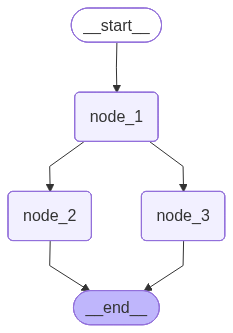

In [89]:
def node_1(state):
    print("---Node 1---")
    return {"foo": [state['foo'][-1] + 1]}

def node_2(state):
    print("---Node 2---")
    return {"foo": [state['foo'][-1] + 1]}

def node_3(state):
    print("---Node 3---")
    return {"foo": [state['foo'][-1] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [90]:
graph.invoke({"foo" : [1]})

---Node 1---
---Node 2---
---Node 3---


{'foo': [1, 2, 3, 3]}

In [91]:
try:
    graph.invoke({"foo" : None})
except TypeError as e:
    print(f"TypeError occurred: {e}")

TypeError occurred: can only concatenate list (not "NoneType") to list


## coustom reducer

In [92]:
def reduce_list(left: list | None, right: list | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class DefaultState(TypedDict):
    foo: Annotated[list[int], add]

class CustomReducerState(TypedDict):
    foo: Annotated[list[int], reduce_list]

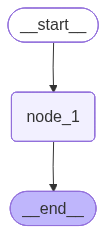

In [93]:
def node_1(state):
    print("---Node 1---")
    return {"foo": [2]}

# Build graph
builder = StateGraph(DefaultState)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))



In [94]:
try:
    print(graph.invoke({"foo" : None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")

TypeError occurred: can only concatenate list (not "NoneType") to list


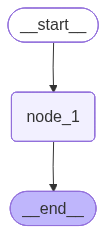

In [95]:
# Build graph
builder = StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [96]:
try:
    print(graph.invoke({"foo" : None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")

---Node 1---
{'foo': [2]}


## add messages

In [97]:
from typing import Annotated
from langgraph.graph import MessagesState
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# Define a custom TypedDict that includes a list of messages with add_messages reducer
class CustomMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    added_key_1: str
    added_key_2: str
    # etc

# Use MessagesState, which includes the messages key with add_messages reducer
class ExtendedMessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    added_key_1: str
    added_key_2: str
    # etc

In [99]:
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage

# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

In [100]:
# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='e4e60805-cf11-42a6-a381-9eb827fbfb58', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='e3dfc84a-f502-4fd2-b50e-f40d696c7f82'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='1332dc61-927f-4c05-8ece-94c50682fa37', tool_calls=[], invalid_tool_calls=[])]

In [101]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model", id="1"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance", id="2")
                   ]

# New message to add
new_message = HumanMessage(content="I'm looking for information on whales, specifically", name="Lance", id="2")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on whales, specifically", additional_kwargs={}, response_metadata={}, name='Lance', id='2')]

## removeMessages

In [102]:
from langchain_core.messages import RemoveMessage

# Message list
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Isolate messages to delete
delete_messages = [RemoveMessage(id=m.id) for m in messages[:-2]]
print(delete_messages)

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2')]


In [103]:
add_messages(messages , delete_messages)

[AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about whales. But what others should I learn about?', additional_kwargs={}, response_metadata={}, name='Lance', id='4')]

## multiple state schema

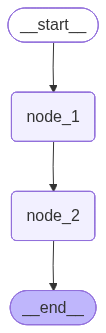

In [104]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class OverallState(TypedDict):
    foo: int

class PrivateState(TypedDict):
    baz: int

def node_1(state: OverallState) -> PrivateState:
    print("---Node 1---")
    return {"baz": state['foo'] + 1}

def node_2(state: PrivateState) -> OverallState:
    print("---Node 2---")
    return {"foo": state['baz'] + 1}

# Build graph
builder = StateGraph(OverallState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [105]:
graph.invoke({"foo" : 1})

---Node 1---
---Node 2---


{'foo': 3}

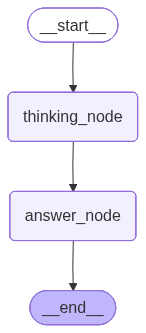

In [114]:
class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: OverallState):
    return {"answer": "bye", "notes": "... his name is Lance"}

def answer_node(state: OverallState):
    return {"answer": "bye Lance"}

graph = StateGraph(OverallState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [115]:
graph.invoke({"question":"hi"})

{'question': 'hi', 'answer': 'bye Lance', 'notes': '... his name is Lance'}

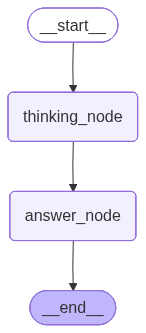

{'answer': 'bye Lance'}

In [116]:
class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: InputState):
    return {"answer": "bye", "notes": "... his is name is Lance"}

def answer_node(state: OverallState) -> OutputState:
    return {"answer": "bye Lance"}

graph = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"question":"hi"})

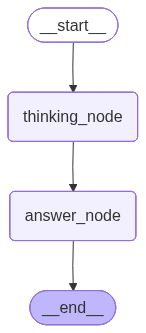

--- Thinking Node ---
--- Answer Node ---

--- OutputState Response ---
{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='77ec41c6-d826-48d0-8287-e316e158ae5a')], 'answer': 'bye Lance'}


In [ ]:
from typing import Literal
from IPython.display import Image, display

# 1. FIXED: Added all mandatory LangGraph and LangChain imports
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import MessagesState, StateGraph, START, END

# --- Define State Schemas ---

class InputState(MessagesState):
    question: str

class OutputState(MessagesState):
    answer: str

class OverallState(MessagesState):
    question: str
    answer: str
    notes: str

# --- Nodes ---

# InputState only exposes 'messages' and 'question' to this node
def thinking_node(state: InputState):
    print("--- Thinking Node ---")
    return {"answer": "bye", "notes": "... his name is Lance"}


# OverallState exposes all fields: 'messages', 'question', 'answer', and 'notes'
def answer_node(state: OverallState):
    print("--- Answer Node ---")
    return {"answer": "bye Lance"}

# --- Build Graph ---

# FIXED: Passed distinct input_schema and output_schema profiles to StateGraph
builder = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)

builder.add_node("thinking_node", thinking_node)
builder.add_node("answer_node", answer_node)

builder.add_edge(START, "thinking_node")
builder.add_edge("thinking_node", "answer_node")
builder.add_edge("answer_node", END)

graph = builder.compile()

# --- View Structure ---
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph compiled! Structural image rendering skipped.")

# --- Invoke Graph ---
# FIXED: Provided an empty 'messages' list channel alongside 'question' 
# to fulfill the mandatory requirements of the inherited MessagesState schema.
response = graph.invoke({
    "question": "hi",
    "messages": [HumanMessage(content="hi")]
})

print("\n--- OutputState Response ---")
print(response)


In [119]:
response['messages']

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='77ec41c6-d826-48d0-8287-e316e158ae5a')]

## parallization

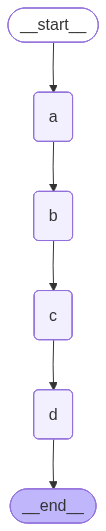

In [121]:
from IPython.display import Image, display

from typing import Any, List
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    # Note, no reducer function. 
    state: List[str]

class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['state']}")
        return {"state": [self._value]}

# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("b", "c")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [122]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm B"]
Adding I'm D to ["I'm C"]


{'state': ["I'm D"]}

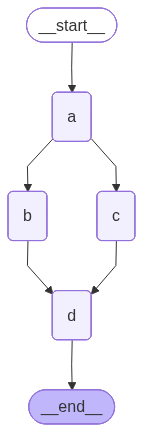

In [123]:
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [124]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"state": []})
except InvalidUpdateError as e:
    print(f"An error occurred: {e}")

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
An error occurred: At key 'state': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


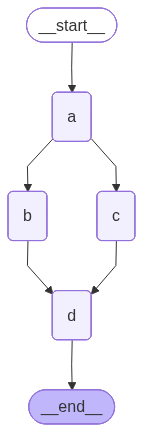

In [125]:
import operator
from typing import Annotated

class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    state: Annotated[list, operator.add]

# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [126]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A", "I'm B", "I'm C"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm D"]}

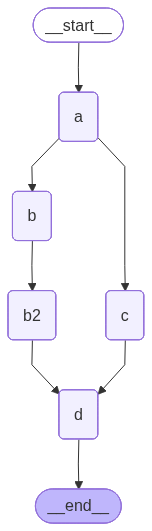

In [127]:
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2", "c"], "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [128]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm C", "I'm B2"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm B2", "I'm D"]}

### Setting the order of state updates

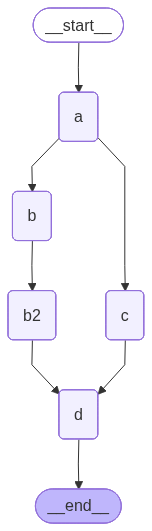

In [130]:
def sorting_reducer(left, right):
    """ Combines and sorts the values in a list"""
    if not isinstance(left, list):
        left = [left]

    if not isinstance(right, list):
        right = [right]
    
    return sorted(left + right, reverse=False)

class State(TypedDict):
    # sorting_reducer will sort the values in state
    state: Annotated[list, sorting_reducer]

# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2", "c"], "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [131]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm B2", "I'm C"]


{'state': ["I'm A", "I'm B", "I'm B2", "I'm C", "I'm D"]}

### work with LLM

In [133]:
from langchain_core.messages import HumanMessage, SystemMessage

from langchain_community.document_loaders import WikipediaLoader
from langchain_tavily import TavilySearch  # updated since filming

C:\Users\smrit\AppData\Local\Temp\ipykernel_16508\4014486901.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader


In [134]:
tavily_search = TavilySearch(max_results=3)
data = tavily_search.invoke({"query": "who is mahatama Gandhi?"})
search_docs = data.get("results", data)

In [135]:
data

{'query': 'who is mahatama Gandhi?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Mahatma_Gandhi',
   'title': 'Mahatma Gandhi - Wikipedia',
   'content': "| Known\xa0for | * Leadership of the campaign for India's independence from British rule * Nonviolent resistance |. **Mohandas Karamchand Gandhi** (/ˈɡɑːndi, ˈɡændi/; *GAHN-dee*; 2 October 1869\xa0– 30 January 1948) was an Indian lawyer, anti-colonial nationalist and political ethicist who employed nonviolent resistance to lead the successful campaign for India's independence from British rule, and to later inspire movements for civil rights and freedom across the world. Born and raised in a Hindu family in coastal Gujarat, Gandhi was trained in the law at the Inner Temple in London and was called to the bar at the age of 22. After two uncertain years in India, where he was unable to start a successful law practice, Gandhi moved to South Africa in 1893 to represent

In [136]:
data.keys()

dict_keys(['query', 'follow_up_questions', 'answer', 'images', 'results', 'response_time', 'request_id'])

In [138]:
data['results']

[{'url': 'https://en.wikipedia.org/wiki/Mahatma_Gandhi',
  'title': 'Mahatma Gandhi - Wikipedia',
  'content': "| Known\xa0for | * Leadership of the campaign for India's independence from British rule * Nonviolent resistance |. **Mohandas Karamchand Gandhi** (/ˈɡɑːndi, ˈɡændi/; *GAHN-dee*; 2 October 1869\xa0– 30 January 1948) was an Indian lawyer, anti-colonial nationalist and political ethicist who employed nonviolent resistance to lead the successful campaign for India's independence from British rule, and to later inspire movements for civil rights and freedom across the world. Born and raised in a Hindu family in coastal Gujarat, Gandhi was trained in the law at the Inner Temple in London and was called to the bar at the age of 22. After two uncertain years in India, where he was unable to start a successful law practice, Gandhi moved to South Africa in 1893 to represent an Indian merchant in a lawsuit.",
  'score': 0.929036,
  'raw_content': None},
 {'url': 'https://www.ebsco.com/

In [139]:
search_docs

[{'url': 'https://en.wikipedia.org/wiki/Mahatma_Gandhi',
  'title': 'Mahatma Gandhi - Wikipedia',
  'content': "| Known\xa0for | * Leadership of the campaign for India's independence from British rule * Nonviolent resistance |. **Mohandas Karamchand Gandhi** (/ˈɡɑːndi, ˈɡændi/; *GAHN-dee*; 2 October 1869\xa0– 30 January 1948) was an Indian lawyer, anti-colonial nationalist and political ethicist who employed nonviolent resistance to lead the successful campaign for India's independence from British rule, and to later inspire movements for civil rights and freedom across the world. Born and raised in a Hindu family in coastal Gujarat, Gandhi was trained in the law at the Inner Temple in London and was called to the bar at the age of 22. After two uncertain years in India, where he was unable to start a successful law practice, Gandhi moved to South Africa in 1893 to represent an Indian merchant in a lawsuit.",
  'score': 0.929036,
  'raw_content': None},
 {'url': 'https://www.ebsco.com/

In [140]:
formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )
formatted_search_docs

'<Document href="https://en.wikipedia.org/wiki/Mahatma_Gandhi">\n| Known\xa0for | * Leadership of the campaign for India\'s independence from British rule * Nonviolent resistance |. **Mohandas Karamchand Gandhi** (/ˈɡɑːndi, ˈɡændi/; *GAHN-dee*; 2 October 1869\xa0– 30 January 1948) was an Indian lawyer, anti-colonial nationalist and political ethicist who employed nonviolent resistance to lead the successful campaign for India\'s independence from British rule, and to later inspire movements for civil rights and freedom across the world. Born and raised in a Hindu family in coastal Gujarat, Gandhi was trained in the law at the Inner Temple in London and was called to the bar at the age of 22. After two uncertain years in India, where he was unable to start a successful law practice, Gandhi moved to South Africa in 1893 to represent an Indian merchant in a lawsuit.\n</Document>\n\n---\n\n<Document href="https://www.ebsco.com/research-starters/history/mahatma-gandhi">\nMahatma Gandhi, bor

In [141]:
print(formatted_search_docs)

In [144]:
search_docs = WikipediaLoader(query="who is mahatama Gandhi?", 
                                  load_max_docs=2).load()

# Format
formatted_search_docs = "\n\n---\n\n".join(
    [
        f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
        for doc in search_docs
    ]
)

In [145]:
search_docs

[Document(metadata={'title': 'Mahatma Gandhi', 'summary': 'Mohandas Karamchand Gandhi (; GAHN-dee; 2 October 1869 – 30 January 1948) was an Indian lawyer, anti-colonial nationalist and political ethicist who employed nonviolent resistance to lead the successful campaign for India\'s independence from British rule, and to later inspire movements for civil rights and freedom across the world. The honorific Mahātmā (Sanskrit: "great-souled", "venerable"), first applied to him in 1914 in South Africa, is now used throughout the world.\nBorn and raised in a Hindu family in coastal Gujarat, Gandhi was trained in the law at the Inner Temple in London and was called to the bar at the age of 22. After two uncertain years in India, where he was unable to start a successful law practice, Gandhi moved to South Africa in 1893 to represent an Indian merchant in a lawsuit. He went on to live in South Africa for the next 21 years. Here, Gandhi raised a family and first employed nonviolent resistance i

In [148]:
search_docs[0].metadata

{'title': 'Mahatma Gandhi',
 'summary': 'Mohandas Karamchand Gandhi (; GAHN-dee; 2 October 1869 – 30 January 1948) was an Indian lawyer, anti-colonial nationalist and political ethicist who employed nonviolent resistance to lead the successful campaign for India\'s independence from British rule, and to later inspire movements for civil rights and freedom across the world. The honorific Mahātmā (Sanskrit: "great-souled", "venerable"), first applied to him in 1914 in South Africa, is now used throughout the world.\nBorn and raised in a Hindu family in coastal Gujarat, Gandhi was trained in the law at the Inner Temple in London and was called to the bar at the age of 22. After two uncertain years in India, where he was unable to start a successful law practice, Gandhi moved to South Africa in 1893 to represent an Indian merchant in a lawsuit. He went on to live in South Africa for the next 21 years. Here, Gandhi raised a family and first employed nonviolent resistance in a campaign for c

In [153]:
print(search_docs[0].metadata['summary'])

Mohandas Karamchand Gandhi (; GAHN-dee; 2 October 1869 – 30 January 1948) was an Indian lawyer, anti-colonial nationalist and political ethicist who employed nonviolent resistance to lead the successful campaign for India's independence from British rule, and to later inspire movements for civil rights and freedom across the world. The honorific Mahātmā (Sanskrit: "great-souled", "venerable"), first applied to him in 1914 in South Africa, is now used throughout the world.
Born and raised in a Hindu family in coastal Gujarat, Gandhi was trained in the law at the Inner Temple in London and was called to the bar at the age of 22. After two uncertain years in India, where he was unable to start a successful law practice, Gandhi moved to South Africa in 1893 to represent an Indian merchant in a lawsuit. He went on to live in South Africa for the next 21 years. Here, Gandhi raised a family and first employed nonviolent resistance in a campaign for civil rights. In 1915, aged 45, he returned 

In [146]:
formatted_search_docs

'<Document source="https://en.wikipedia.org/wiki/Mahatma_Gandhi" page="">\nMohandas Karamchand Gandhi (; GAHN-dee; 2 October 1869 – 30 January 1948) was an Indian lawyer, anti-colonial nationalist and political ethicist who employed nonviolent resistance to lead the successful campaign for India\'s independence from British rule, and to later inspire movements for civil rights and freedom across the world. The honorific Mahātmā (Sanskrit: "great-souled", "venerable"), first applied to him in 1914 in South Africa, is now used throughout the world.\nBorn and raised in a Hindu family in coastal Gujarat, Gandhi was trained in the law at the Inner Temple in London and was called to the bar at the age of 22. After two uncertain years in India, where he was unable to start a successful law practice, Gandhi moved to South Africa in 1893 to represent an Indian merchant in a lawsuit. He went on to live in South Africa for the next 21 years. Here, Gandhi raised a family and first employed nonviol

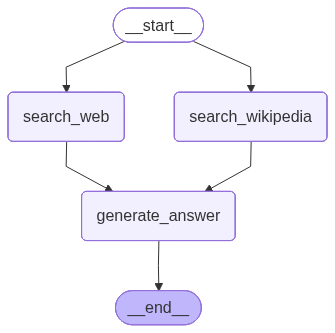

In [154]:
from langchain_core.messages import HumanMessage, SystemMessage

from langchain_community.document_loaders import WikipediaLoader
from langchain_tavily import TavilySearch  # updated since filming



class State(TypedDict):
    question: str
    answer: str
    context: Annotated[list, operator.add]
   

def search_web(state):
    
    """ Retrieve docs from web search """

    # Search
    tavily_search = TavilySearch(max_results=3)
    data = tavily_search.invoke({"query": state['question']})
    search_docs = data.get("results", data)

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

def search_wikipedia(state):
    
    """ Retrieve docs from wikipedia """

    # Search
    search_docs = WikipediaLoader(query=state['question'], 
                                  load_max_docs=2).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

def generate_answer(state):
    
    """ Node to answer a question """

    # Get state
    context = state["context"]
    question = state["question"]

    # Template
    answer_template = """Answer the question {question} using this context: {context}"""
    answer_instructions = answer_template.format(question=question, 
                                                       context=context)    
    
    # Answer
    answer = llm.invoke([SystemMessage(content=answer_instructions)]+[HumanMessage(content=f"Answer the question.")])
      
    # Append it to state
    return {"answer": answer}


# llm = ChatOpenAI(model="gpt-4o", temperature=0) 


# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("search_web",search_web)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)

# Flow
builder.add_edge(START, "search_wikipedia")
builder.add_edge(START, "search_web")
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
result = graph.invoke({"question": "How were Nvidia's Q2 2025 earnings"})
result['answer'].content

In [ ]:
class State(MessagesState):
    context: Annotated[list, operator.add]

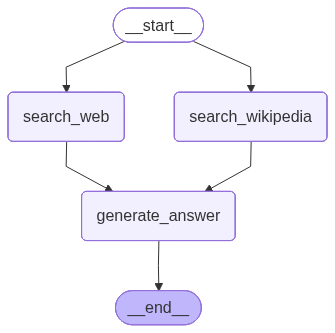

In [155]:
from langchain_core.messages import HumanMessage, SystemMessage

from langchain_community.document_loaders import WikipediaLoader
from langchain_tavily import TavilySearch  # updated since filming



class State(MessagesState):
    question: str
    answer: str
    context: Annotated[list, operator.add]
   

def search_web(state):
    """ Retrieve docs from web search """
    # Search
    tavily_search = TavilySearch(max_results=3)
    data = tavily_search.invoke({"query": state['question']})
    search_docs = data.get("results", data)

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs],  "messages": [
            AIMessage(content="Retrieved documents from Tavily")
        ]} 

def search_wikipedia(state):
    
    """ Retrieve docs from wikipedia """

    # Search
    search_docs = WikipediaLoader(query=state['question'], 
                                  load_max_docs=2).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs],  "messages": [
            AIMessage(content="Retrieved documents from Wiki")
        ]} 

def generate_answer(state):
    
    """ Node to answer a question """

    # Get state
    context = state["context"]
    question = state["question"]

    # Template
    answer_template = """Answer the question {question} using this context: {context}"""
    answer_instructions = answer_template.format(question=question, 
                                                       context=context)    
    
    # Answer
    answer = llm.invoke([SystemMessage(content=answer_instructions)]+[HumanMessage(content=f"Answer the question.")])
      
    # Append it to state
    return {"answer": answer,  "messages": [answer]}


# llm = ChatOpenAI(model="gpt-4o", temperature=0) 


# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("search_web",search_web)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)

# Flow
builder.add_edge(START, "search_wikipedia")
builder.add_edge(START, "search_web")
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [156]:
result = graph.invoke({"question": "who is mahatama gandhi reply in one sentence?"})
result['answer'].content

'Mahatma Gandhi, born Mohandas\u202fKaramchand\u202fGandhi and honored in India as\u202fBapu\u202for\u202fRastrapita, was the leader of the nation’s independence movement who famously declared that his life itself was his message.'

In [157]:
print(result['answer'].content)

Mahatma Gandhi, born Mohandas Karamchand Gandhi and honored in India as Bapu or Rastrapita, was the leader of the nation’s independence movement who famously declared that his life itself was his message.


In [158]:
result

{'messages': [AIMessage(content='Retrieved documents from Tavily', additional_kwargs={}, response_metadata={}, id='d4cef0cb-4211-4d50-9457-f8fd976d0242', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Retrieved documents from Wiki', additional_kwargs={}, response_metadata={}, id='6fe35ba1-c7c2-4397-a428-9f4c86cf221f', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Mahatma Gandhi, born Mohandas\u202fKaramchand\u202fGandhi and honored in India as\u202fBapu\u202for\u202fRastrapita, was the leader of the nation’s independence movement who famously declared that his life itself was his message.', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-25T03:49:27.254725911Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2061146300, 'load_duration': None, 'prompt_eval_count': 1223, 'prompt_eval_duration': None, 'eval_count': 245, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'mod

In [159]:
result['messages']

[AIMessage(content='Retrieved documents from Tavily', additional_kwargs={}, response_metadata={}, id='d4cef0cb-4211-4d50-9457-f8fd976d0242', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Retrieved documents from Wiki', additional_kwargs={}, response_metadata={}, id='6fe35ba1-c7c2-4397-a428-9f4c86cf221f', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Mahatma Gandhi, born Mohandas\u202fKaramchand\u202fGandhi and honored in India as\u202fBapu\u202for\u202fRastrapita, was the leader of the nation’s independence movement who famously declared that his life itself was his message.', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-25T03:49:27.254725911Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2061146300, 'load_duration': None, 'prompt_eval_count': 1223, 'prompt_eval_duration': None, 'eval_count': 245, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': '

In [ ]:
print(result['messages'][-1].content)

'Mahatma Gandhi, born Mohandas\u202fKaramchand\u202fGandhi and honored in India as\u202fBapu\u202for\u202fRastrapita, was the leader of the nation’s independence movement who famously declared that his life itself was his message.'

In [162]:
print(result['messages'][-1].content)

Mahatma Gandhi, born Mohandas Karamchand Gandhi and honored in India as Bapu or Rastrapita, was the leader of the nation’s independence movement who famously declared that his life itself was his message.


In [163]:
result['messages']

[AIMessage(content='Retrieved documents from Tavily', additional_kwargs={}, response_metadata={}, id='d4cef0cb-4211-4d50-9457-f8fd976d0242', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Retrieved documents from Wiki', additional_kwargs={}, response_metadata={}, id='6fe35ba1-c7c2-4397-a428-9f4c86cf221f', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Mahatma Gandhi, born Mohandas\u202fKaramchand\u202fGandhi and honored in India as\u202fBapu\u202for\u202fRastrapita, was the leader of the nation’s independence movement who famously declared that his life itself was his message.', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-25T03:49:27.254725911Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2061146300, 'load_duration': None, 'prompt_eval_count': 1223, 'prompt_eval_duration': None, 'eval_count': 245, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': '

## sub graph

### RAG Failure Analysis and Observability Agent based on the RAG logs

In [1]:
from operator import add
from typing_extensions import TypedDict
from typing import List, Optional, Annotated
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# The structure of the logs
class Log(TypedDict):
    id: str
    question: str
    docs: Optional[List]
    answer: str
    grade: Optional[int]
    grader: Optional[str]
    feedback: Optional[str]



# Failure Analysis Sub-graph
class FailureAnalysisState(TypedDict):
    cleaned_logs: List[Log]
    failures: List[Log]
    fa_summary: str
    processed_logs: List[str]

class FailureAnalysisOutputState(TypedDict):
    fa_summary: str
    processed_logs: List[str]




# Summarization subgraph
class QuestionSummarizationState(TypedDict):
    cleaned_logs: List[Log]
    qs_summary: str
    report: str
    processed_logs: List[str]

class QuestionSummarizationOutputState(TypedDict):
    report: str
    processed_logs: List[str]


In [2]:
# The structure of the logs
class Log(TypedDict):
    id: str
    question: str
    docs: Optional[List]
    answer: str
    grade: Optional[int]
    grader: Optional[str]
    feedback: Optional[str]


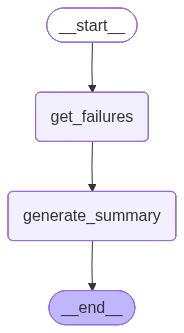

In [3]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Failure Analysis Sub-graph
class FailureAnalysisState(TypedDict):
    cleaned_logs: List[Log]
    failures: List[Log]
    fa_summary: str
    processed_logs: List[str]

class FailureAnalysisOutputState(TypedDict):
    fa_summary: str
    processed_logs: List[str]

def get_failures(state):
    """ Get logs that contain a failure """
    cleaned_logs = state["cleaned_logs"]
    failures = [log for log in cleaned_logs if "grade" in log]
    return {"failures": failures}

def generate_summary(state):
    """ Generate summary of failures """
    failures = state["failures"]
    # Add fxn: fa_summary = summarize(failures)
    fa_summary = "Poor quality retrieval of Chroma documentation."
    return {"fa_summary": fa_summary, "processed_logs": [f"failure-analysis-on-log-{failure['id']}" for failure in failures]}

fa_builder = StateGraph(state_schema=FailureAnalysisState,output_schema=FailureAnalysisOutputState)
fa_builder.add_node("get_failures", get_failures)
fa_builder.add_node("generate_summary", generate_summary)
fa_builder.add_edge(START, "get_failures")
fa_builder.add_edge("get_failures", "generate_summary")
fa_builder.add_edge("generate_summary", END)

graph = fa_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

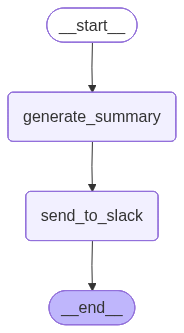

In [4]:
# Summarization subgraph
class QuestionSummarizationState(TypedDict):
    cleaned_logs: List[Log]
    qs_summary: str
    report: str
    processed_logs: List[str]

class QuestionSummarizationOutputState(TypedDict):
    report: str
    processed_logs: List[str]

def generate_summary(state):
    cleaned_logs = state["cleaned_logs"]
    # Add fxn: summary = summarize(generate_summary)
    summary = "Questions focused on usage of ChatOllama and Chroma vector store."
    return {"qs_summary": summary, "processed_logs": [f"summary-on-log-{log['id']}" for log in cleaned_logs]}

def send_to_slack(state):
    qs_summary = state["qs_summary"]
    # Add fxn: report = report_generation(qs_summary)
    report = "foo bar baz"
    return {"report": report}

qs_builder = StateGraph(QuestionSummarizationState,output_schema=QuestionSummarizationOutputState)
qs_builder.add_node("generate_summary", generate_summary)
qs_builder.add_node("send_to_slack", send_to_slack)
qs_builder.add_edge(START, "generate_summary")
qs_builder.add_edge("generate_summary", "send_to_slack")
qs_builder.add_edge("send_to_slack", END)

graph = qs_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# Entry Graph
class EntryGraphState(TypedDict):
    raw_logs: List[Log]
    cleaned_logs: Annotated[List[Log], add] # This will be USED BY in BOTH sub-graphs
    fa_summary: str # This will only be generated in the FA sub-graph
    report: str # This will only be generated in the QS sub-graph
    processed_logs:  Annotated[List[int], add] # This will be generated in BOTH sub-graphs

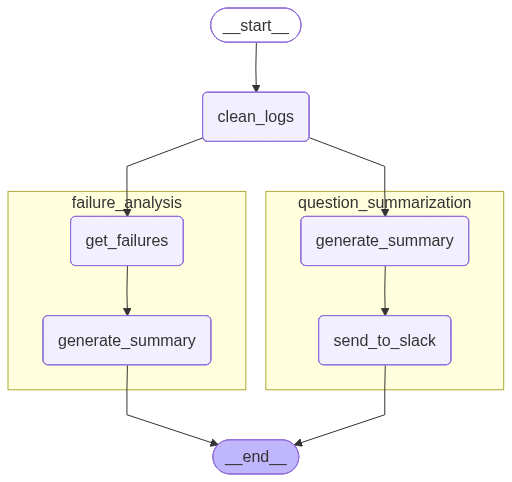

In [6]:
# Entry Graph
class EntryGraphState(TypedDict):
    raw_logs: List[Log]
    cleaned_logs: List[Log]
    fa_summary: str # This will only be generated in the FA sub-graph
    report: str # This will only be generated in the QS sub-graph
    processed_logs:  Annotated[List[int], add] # This will be generated in BOTH sub-graphs

def clean_logs(state):
    # Get logs
    raw_logs = state["raw_logs"]
    # Data cleaning raw_logs -> docs 
    cleaned_logs = raw_logs
    return {"cleaned_logs": cleaned_logs}

entry_builder = StateGraph(EntryGraphState)
entry_builder.add_node("clean_logs", clean_logs)
entry_builder.add_node("question_summarization", qs_builder.compile())
entry_builder.add_node("failure_analysis", fa_builder.compile())

entry_builder.add_edge(START, "clean_logs")
entry_builder.add_edge("clean_logs", "failure_analysis")
entry_builder.add_edge("clean_logs", "question_summarization")
entry_builder.add_edge("failure_analysis", END)
entry_builder.add_edge("question_summarization", END)

graph = entry_builder.compile()

from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [7]:
# Dummy logs
question_answer = Log(
    id="1",
    question="How can I import ChatOllama?",
    answer="To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'",
)

question_answer_feedback = Log(
    id="2",
    question="How can I use Chroma vector store?",
    answer="To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).",
    grade=0,
    grader="Document Relevance Recall",
    feedback="The retrieved documents discuss vector stores in general, but not Chroma specifically",
)

raw_logs = [question_answer,question_answer_feedback]
result= graph.invoke({"raw_logs": raw_logs})

In [8]:
result

{'raw_logs': [{'id': '1',
   'question': 'How can I import ChatOllama?',
   'answer': "To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'"},
  {'id': '2',
   'question': 'How can I use Chroma vector store?',
   'answer': 'To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).',
   'grade': 0,
   'grader': 'Document Relevance Recall',
   'feedback': 'The retrieved documents discuss vector stores in general, but not Chroma specifically'}],
 'cleaned_logs': [{'id': '1',
   'question': 'How can I import ChatOllama?',
   'answer': "To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'"},
  {'id': '2',
   'question': 'How can I use Chroma vector store?',
   'answer': 'To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).',
   'grade': 0,
   'grader': 'Document Relevance Recall',
   'feedback': 'The retrieved documents discuss vector stores in general, 

In [9]:
result.keys()

dict_keys(['raw_logs', 'cleaned_logs', 'fa_summary', 'report', 'processed_logs'])

## Map reducer 

In [10]:
from langchain_openai import ChatOpenAI

# Prompts we will use
subjects_prompt = """Generate a list of 3 sub-topics that are all related to this overall topic: {topic}."""
joke_prompt = """Generate a joke about {subject}"""
best_joke_prompt = """Below are a bunch of jokes about {topic}. Select the best one! Return the ID of the best one, starting 0 as the ID for the first joke. Jokes: \n\n  {jokes}"""

# LLM
# model = ChatOpenAI(model="gpt-4o", temperature=0) 


KeyboardInterrupt



## Joke generation parallization

### execution process

In [42]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel


topic: animals ---> sub topics:['Animal habitats', 'Animal migration', 'Animal communication']

best joke:

In [ ]:
# TOPIC: 
topic = "animals"

# SUB TOPICS: 
subjects_prompt = """Generate a list of 3 sub-topics that are all related to this overall topic: {topic}."""
{'generate_topics': {'subjects': ['mammals', 'reptiles', 'birds']}}

# JOKE for each TOPIC:
joke_prompt = """Generate a joke about {subject}"""
#1 mammal
{'generate_joke': {'jokes': ["Why don't mammals ever get lost? Because they always follow their 'instincts'!"]}}
#2 reptaile
{'generate_joke': {'jokes': ["Why don't alligators like fast food? Because they can't catch it!"]}}
#3 birds
{'generate_joke': {'jokes': ["Why do birds fly south for the winter? Because it's too far to walk!"]}}

# select best joke out of generated
best_joke_prompt = """Below are a bunch of jokes about {topic}. Select the best one! Return the ID of the best one, starting 0 as the ID for the first joke. Jokes: \n\n  {jokes}"""

{'best_joke': {'best_selected_joke': "Why don't alligators like fast food? Because they can't catch it!"}}

{'best_joke': {'best_selected_joke': "Why don't alligators like fast food? Because they can't catch it!"}}

#### sub topic generation

In [26]:
from pydantic import BaseModel

class Subjects(BaseModel):
    subjects: list[str]

# 1. Update the prompt to give strict JSON rules
subjects_prompt = """
Generate a list of 3 sub-topics that are all related to this overall topic: {topic}.

You must respond ONLY with a JSON object matching this structure. Do not include any introduction, explanations, or conversational filler.

Expected JSON format:
{{
    "subjects": ["Sub-topic 1", "Sub-topic 2", "Sub-topic 3"]
}}
"""

# 2. Format and invoke
prompt = subjects_prompt.format(topic="animals")
response = llm2.with_structured_output(Subjects).invoke(prompt)

print(response.subjects)


['Animal habitats', 'Animal migration', 'Animal communication']


In [27]:
print(prompt)


Generate a list of 3 sub-topics that are all related to this overall topic: animals.

You must respond ONLY with a JSON object matching this structure. Do not include any introduction, explanations, or conversational filler.

Expected JSON format:
{
    "subjects": ["Sub-topic 1", "Sub-topic 2", "Sub-topic 3"]
}



In [28]:
response

Subjects(subjects=['Animal habitats', 'Animal migration', 'Animal communication'])

In [31]:
response.subjects[0]

'Animal habitats'

### joke generation for each sub topic

In [37]:
class JokeState(TypedDict):
    subject: str

class Joke(BaseModel):
    joke: str
joke_prompt = """
Generate a small joke about {subject}.

You must respond ONLY with a valid JSON object matching this structure:
{{
    "joke": "Your joke text here"
}}
"""

prompt = joke_prompt.format(subject='Animal habitats')
response = llm2.with_structured_output(Joke).invoke(prompt)


In [38]:
response

Joke(joke="Why did the fish go to school? To improve its 'school' of thought about ocean habitats.")

### best joke selection out of generated joke 

In [40]:
class BestJoke(BaseModel):
    id: int
    
# 2. Update the prompt to enforce strict JSON structure
best_joke_prompt = """
Below are a bunch of jokes about {topic}. Select the best one!

Jokes:
{jokes}

You must return ONLY a JSON object matching this structure. Do not include any introduction or markdown formatting wrapper except the JSON itself.

Expected JSON format:
{{
    "id": 0
}}
"""

formatted_jokes = "0: Why did the fish go to school? To improve its 'school' of thought about ocean habitats \n1: What do you call a dog kuta"
prompt = best_joke_prompt.format(topic="animals", jokes=formatted_jokes)
response = llm2.with_structured_output(BestJoke).invoke(prompt)


In [41]:
response

BestJoke(id=0)

### combined code

In [48]:
print(subjects_prompt)
print("---" * 30)
print(joke_prompt)
print("---" * 30)
print(best_joke_prompt)


Generate a list of 3 sub-topics that are all related to this overall topic: {topic}.

You must respond ONLY with a JSON object matching this structure. Do not include any introduction, explanations, or conversational filler.

Expected JSON format:
{{
    "subjects": ["Sub-topic 1", "Sub-topic 2", "Sub-topic 3"]
}}

------------------------------------------------------------------------------------------

Generate a small joke about {subject}.

You must respond ONLY with a valid JSON object matching this structure:
{{
    "joke": "Your joke text here"
}}

------------------------------------------------------------------------------------------

Below are a bunch of jokes about {topic}. Select the best one!

Jokes:
{jokes}

You must return ONLY a JSON object matching this structure. Do not include any introduction or markdown formatting wrapper except the JSON itself.

Expected JSON format:
{{
    "id": 0
}}



In [49]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel

class Subjects(BaseModel):
    subjects: list[str]

class BestJoke(BaseModel):
    id: int
    
class OverallState(TypedDict):
    topic: str
    subjects: list
    jokes: Annotated[list, operator.add]
    best_selected_joke: str

In [50]:
def generate_topics(state: OverallState):
    prompt = subjects_prompt.format(topic=state["topic"])
    response = llm2.with_structured_output(Subjects).invoke(prompt)
    return {"subjects": response.subjects}

In [51]:
from langgraph.types import Send
def continue_to_jokes(state: OverallState):
    return [Send("generate_joke", {"subject": s}) for s in state["subjects"]]

In [ ]:
state = {}
state['subjects'] = ['Animal habitats', 'Animal migration', 'Animal communication']
continue_to_jokes(state)

[Send(node='generate_joke', arg={'subject': 'Animal habitats'}),
 Send(node='generate_joke', arg={'subject': 'Animal migration'}),
 Send(node='generate_joke', arg={'subject': 'Animal communication'})]

In [53]:
#### joke generation
class JokeState(TypedDict):
    subject: str

class Joke(BaseModel):
    joke: str

def generate_joke(state: JokeState):
    prompt = joke_prompt.format(subject=state["subject"])
    response = llm2.with_structured_output(Joke).invoke(prompt)
    return {"jokes": [response.joke]}

In [ ]:
#### best joke

def best_joke(state: OverallState):
    jokes = "\n\n".join(state["jokes"])
    prompt = best_joke_prompt.format(topic=state["topic"], jokes=jokes)
    response = llm2.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke": state["jokes"][response.id]}

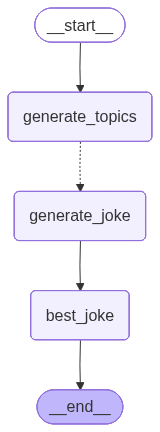

In [55]:
from IPython.display import Image
from langgraph.graph import END, StateGraph, START

# Construct the graph: here we put everything together to construct our graph
graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", generate_joke)
graph.add_node("best_joke", best_joke)
graph.add_edge(START, "generate_topics")
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)

# Compile the graph
app = graph.compile()
Image(app.get_graph().draw_mermaid_png())

In [ ]:
# Call the graph: here we call it to generate a list of jokes
for s in app.stream({"topic": "animals"}):
    print(s)

In [ ]:
# Call the graph: here we call it to generate a list of jokes
for s in app.stream({"topic": "animals"}):
    print(s)

{'generate_topics': {'subjects': ['mammals', 'reptiles', 'birds']}}
{'generate_joke': {'jokes': ["Why don't mammals ever get lost? Because they always follow their 'instincts'!"]}}
{'generate_joke': {'jokes': ["Why don't alligators like fast food? Because they can't catch it!"]}}
{'generate_joke': {'jokes': ["Why do birds fly south for the winter? Because it's too far to walk!"]}}
{'best_joke': {'best_selected_joke': "Why don't alligators like fast food? Because they can't catch it!"}}
